# Projet AI & Optimization 2025 / 2026
## Classification de cellules sur images histologiques

**Membres de l'equipe :** *(a completer)*
- Camille Chaptini
- *Nom 2 (si binome/trinome)*
- *Nom 3 (si trinome)*

---

### Objectif

Classifier automatiquement des patchs d'images histologiques en H&E
(Hematoxyline-Eosine) dans l'une des quatre categories :
**Lymphocyte**, **Tumor**, **Plasma**, **Fibroblast**.

### Plan (impose par les consignes)

1. **Exploration des donnees** : nombre de samples, distribution des
   labels, apparence par classe.
2. **Extraction de features homemade** : descripteurs d'aire, de forme,
   d'intensite, codes a la main en pur `numpy` / `scipy.ndimage`
   (techniques vues en Lab 01).
3. **Entrainement des modeles** : on utilise uniquement les methodes
   vues dans les **CM 08, 09 et 10** (ANOVA, GridSearch/RandomizedSearch,
   Logistic Regression / L-BFGS, SVM, SGD).
4. **Prediction sur le futur test set** : fonction prete a l'emploi
   pour produire `test.csv`.

### Correspondance methode -> cours

| Methode                   | Source                                  |
| ------------------------- | --------------------------------------- |
| `StandardScaler`          | CM 10, slide 20 (practical tricks SGD)  |
| `StratifiedKFold` 5-fold  | CM 09, slides 13-14 (KFold stratifie)    |
| `SelectKBest` (`f_classif`) | CM 09, slides 19, 24-25 (ANOVA)        |
| `GridSearchCV`            | CM 09, slide 40                          |
| `RandomizedSearchCV`      | CM 09, slides 41-42                      |
| `LogisticRegression`      | CM 08 (ML overview) + CM 10 slide 11    |
| Solveur **L-BFGS**        | CM 10, slides 6-11                       |
| **SVM** lineaire          | CM 09 (illustrations RFE / SFS / SVM)    |
| **SGDClassifier**         | CM 10, slides 15-22                      |


## 0. Imports et chemins

Imports limites au strict necessaire. Aucune librairie externe au-dela
de ce qui est utilise dans les CM.


In [1]:
# Imports systeme
import os
import warnings
warnings.filterwarnings("ignore")

# Calcul
import numpy as np
import pandas as pd
from PIL import Image
import scipy.ndimage as ndi  # comme en Lab 01

# Plot
import matplotlib.pyplot as plt

# ML : uniquement les outils vus dans les CM 08, 09, 10
from sklearn.model_selection import (
    StratifiedKFold,        # CM 09 slide 13
    cross_val_score,        # utilise dans tous les CM
    GridSearchCV,           # CM 09 slide 40
    RandomizedSearchCV,     # CM 09 slide 41
    cross_val_predict,
)
from sklearn.preprocessing import StandardScaler        # CM 10 slide 20
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    SelectKBest, f_classif,                              # CM 09 slide 19
)
from sklearn.linear_model import (
    LogisticRegression,     # CM 08 + CM 10 (L-BFGS, slide 11)
    SGDClassifier,          # CM 10 slides 15-22
)
from sklearn.svm import SVC                              # CM 09
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)
from scipy.stats import loguniform                      # pour RandomizedSearch

# Reproductibilite
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Chemins (notebook a la racine du projet)
DATA_DIR     = "."
IMG_DIR      = os.path.join(DATA_DIR, "DATASET_images")
TRAIN_CSV    = os.path.join(DATA_DIR, "train.csv")
FEATURES_CSV = os.path.join(DATA_DIR, "features_train.csv")

print("Dossier images :", IMG_DIR)
print("Fichier train  :", TRAIN_CSV)

Dossier images : ./DATASET_images
Fichier train  : ./train.csv


## 1. Exploration des donnees (obligatoire)

### a) Chargement et statistiques


In [2]:
# Important : on force la colonne Image en string pour preserver
# les zeros de tete (les ids sont "00", "01", ..., "99")
train_df = pd.read_csv(TRAIN_CSV, dtype={"Image": str})
print(f"Nombre total d'echantillons : {len(train_df)}")
print(f"Colonnes : {list(train_df.columns)}")
train_df.head()

Nombre total d'echantillons : 400
Colonnes : ['Image', 'Label']


,Image,Label
0,00,Lymphocyte
1,01,Tumor
2,02,Tumor
3,03,Lymphocyte
4,04,Plasma


In [3]:
# Distribution des labels
counts = train_df["Label"].value_counts()
print("Distribution :")
print(counts)
print()
print("Proportions :")
print((counts / counts.sum()).round(3))

Distribution :
Label
Lymphocyte    100
Tumor         100
Plasma        100
Fibroblast    100
Name: count, dtype: int64

Proportions :
Label
Lymphocyte    0.25
Tumor         0.25
Plasma        0.25
Fibroblast    0.25
Name: count, dtype: float64


Dataset **parfaitement equilibre** : 100 images par classe, 400
au total. Pas besoin de jouer sur les ponderations de classes.


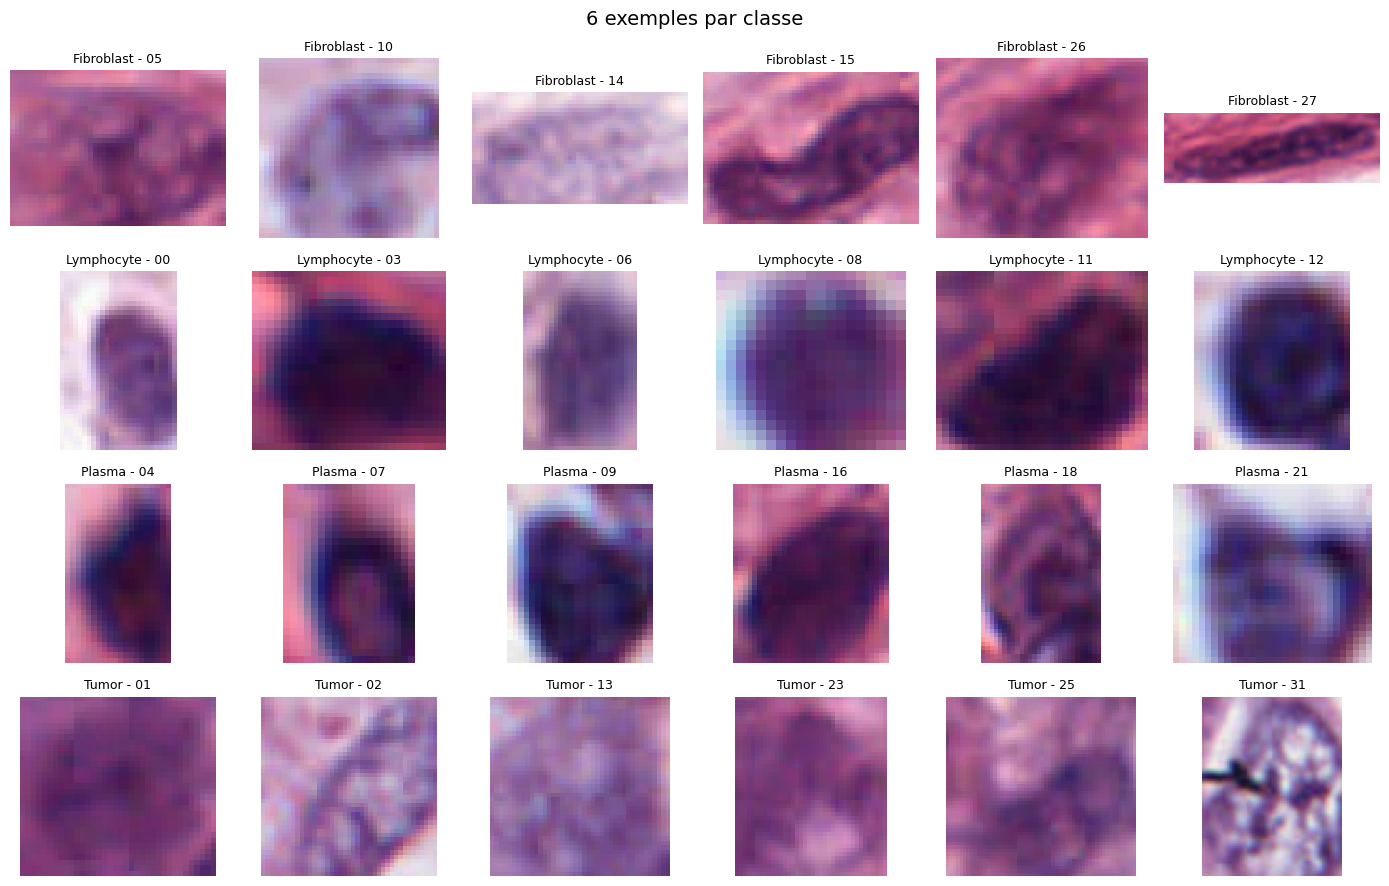

In [4]:
# Un echantillon de chaque classe
fig, axes = plt.subplots(4, 6, figsize=(14, 9))
for ci, (cls, sub) in enumerate(train_df.groupby("Label")):
    sample_ids = sub["Image"].head(6).tolist()
    for j, im_id in enumerate(sample_ids):
        img = np.array(Image.open(
            os.path.join(IMG_DIR, im_id + ".png")
        ))
        axes[ci, j].imshow(img)
        axes[ci, j].set_title(f"{cls} - {im_id}", fontsize=9)
        axes[ci, j].axis("off")
plt.suptitle("6 exemples par classe", fontsize=14)
plt.tight_layout()
plt.show()

### b) Tailles des patchs

Les patchs n'ont pas tous la meme taille. On regarde si la taille
porte de l'information sur la classe.


In [5]:
records = []
for _, row in train_df.iterrows():
    img = np.array(Image.open(
        os.path.join(IMG_DIR, row["Image"] + ".png")
    ))
    h, w = img.shape[:2]
    records.append({"Label": row["Label"], "h": h, "w": w,
                    "area": h * w})
size_df = pd.DataFrame(records)
print(size_df.groupby("Label")[["h", "w", "area"]].mean().round(1))

               h     w    area
Label                         
Fibroblast  43.5  48.9  2100.7
Lymphocyte  26.5  26.4   716.5
Plasma      27.6  28.0   780.9
Tumor       43.6  47.2  2111.8


**Observations** :

- **Lymphocyte** : petit (~25 px), tres dense.
- **Plasma** : taille proche du Lymphocyte mais avec couronne rose.
- **Tumor** : plus gros (~45 px), forme arrondie.
- **Fibroblast** : allonge (largeur >> hauteur).

Lymphocyte et Plasma se ressemblent visuellement, c'est la plus grosse
difficulte du probleme.


## 2. Extraction des features homemade (obligatoire)

Comme demande dans les consignes, on code **a la main** les features
en pur `numpy` / `scipy.ndimage` (techniques vues en Lab 01).
On extrait trois familles : aire/forme, intensite, texture.


### a) Conversion RGB -> HSV (faite a la main)


In [6]:
def rgb_to_hsv(rgb):
    # Conversion canal par canal (chaque canal dans [0, 1])
    img = rgb.astype(np.float32) / 255.0
    R, G, B = img[..., 0], img[..., 1], img[..., 2]
    maxc = np.maximum(np.maximum(R, G), B)
    minc = np.minimum(np.minimum(R, G), B)
    V = maxc
    delta = maxc - minc
    S = np.where(maxc > 1e-6, delta / (maxc + 1e-9), 0.0)
    H = np.zeros_like(R)
    msk = delta > 1e-6
    rc = np.where(msk, (maxc - R) / (delta + 1e-9), 0.0)
    gc = np.where(msk, (maxc - G) / (delta + 1e-9), 0.0)
    bc = np.where(msk, (maxc - B) / (delta + 1e-9), 0.0)
    H = np.where(R == maxc, bc - gc, H)
    H = np.where(G == maxc, 2.0 + rc - bc, H)
    H = np.where(B == maxc, 4.0 + gc - rc, H)
    H = (H / 6.0) % 1.0
    H[~msk] = 0.0
    return H, S, V

### b) Seuillage d'Otsu maison + segmentation du noyau

Sur une image H&E, le noyau est riche en hematoxyline, donc tres
sombre sur le canal vert. On seuille avec Otsu sur le canal `B - G`
(= proxy de l'hematoxyline), on bouche les trous (vu en Lab 01), on
garde la composante connexe qui contient le centre du patch.


In [7]:
def otsu_threshold(arr):
    # Seuil d'Otsu : maximise la variance inter-classe
    flat = arr.ravel()
    hist, edges = np.histogram(flat, bins=64,
                                range=(flat.min(), flat.max()))
    hist = hist.astype(np.float64)
    total = hist.sum()
    if total == 0:
        return 0.0
    p = hist / total
    cum_p = np.cumsum(p)
    mids = (edges[:-1] + edges[1:]) / 2.0
    cum_m = np.cumsum(p * mids)
    mu_t = cum_m[-1]
    sigma2_b = ((mu_t * cum_p - cum_m) ** 2
                / (cum_p * (1 - cum_p) + 1e-12))
    return float(mids[int(np.argmax(sigma2_b))])


def segment_nucleus(img_rgb):
    img = img_rgb.astype(np.float32) / 255.0
    nuclear = img[..., 2] - img[..., 1]  # B - G
    thr = otsu_threshold(nuclear)
    mask = (nuclear >= thr).astype(np.uint8)
    mask = ndi.binary_fill_holes(mask).astype(np.uint8)
    if mask.sum() < 5:
        # Fallback simple si Otsu rate
        g = img_rgb[:, :, 1].astype(np.float32)
        mask = (g <= g.mean() - 0.3 * g.std()).astype(np.uint8)
        mask = ndi.binary_fill_holes(mask).astype(np.uint8)
    ccs, n = ndi.label(mask)
    if n == 0:
        return mask
    h, w = mask.shape
    central = ccs[h // 2, w // 2]
    if central > 0:
        chosen = central
    else:
        ids, counts = np.unique(ccs[ccs > 0], return_counts=True)
        chosen = ids[np.argmax(counts)]
    return (ccs == chosen).astype(np.uint8)

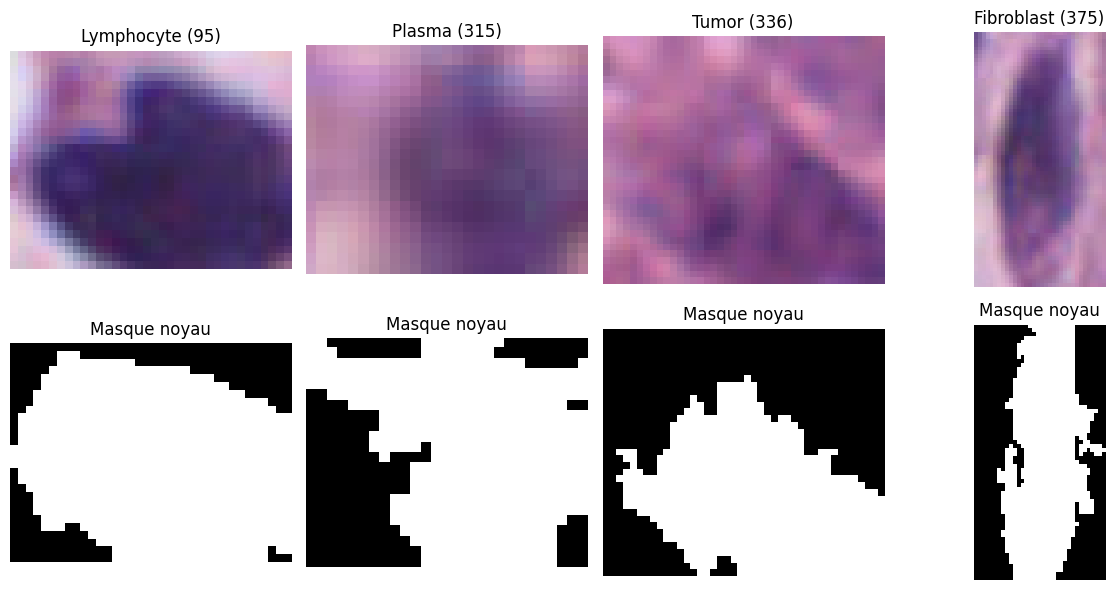

In [8]:
# Controle visuel
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for k, cls in enumerate(["Lymphocyte", "Plasma", "Tumor", "Fibroblast"]):
    im_id = train_df[train_df["Label"] == cls].sample(
        1, random_state=k).iloc[0]["Image"]
    img = np.array(Image.open(os.path.join(IMG_DIR, im_id + ".png")))
    mask = segment_nucleus(img)
    ax[0, k].imshow(img); ax[0, k].set_title(f"{cls} ({im_id})")
    ax[0, k].axis("off")
    ax[1, k].imshow(mask, cmap="gray"); ax[1, k].set_title("Masque noyau")
    ax[1, k].axis("off")
plt.tight_layout(); plt.show()

### c) Features d'aire et de forme

A partir du masque binaire : aire, perimetre, circularite, bounding
box, allongement, excentricite (PCA sur les pixels du masque).


In [9]:
def shape_features(mask):
    feats = {}
    area = float(mask.sum())
    feats["area"]       = area
    feats["area_ratio"] = area / (mask.size + 1e-9)
    if area < 3:
        feats.update({
            "perimeter": 0.0, "circularity": 0.0,
            "bbox_h": 0.0, "bbox_w": 0.0, "bbox_fill": 0.0,
            "elongation": 1.0, "eccentricity": 0.0,
        })
        return feats
    eroded = ndi.binary_erosion(mask).astype(np.uint8)
    perimeter = float((mask - eroded).sum())
    feats["perimeter"]   = perimeter
    feats["circularity"] = float(
        4.0 * np.pi * area / (perimeter ** 2 + 1e-9))
    xs, ys = np.where(mask)
    bbox_h = xs.max() - xs.min() + 1
    bbox_w = ys.max() - ys.min() + 1
    feats["bbox_h"]    = float(bbox_h)
    feats["bbox_w"]    = float(bbox_w)
    feats["bbox_fill"] = float(area / (bbox_h * bbox_w + 1e-9))
    feats["elongation"] = float(
        max(bbox_h, bbox_w) / (min(bbox_h, bbox_w) + 1e-9))
    # Excentricite via PCA sur les pixels du masque
    dx = xs - xs.mean(); dy = ys - ys.mean()
    cov = np.array([
        [(dx * dx).mean(), (dx * dy).mean()],
        [(dx * dy).mean(), (dy * dy).mean()],
    ])
    eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]
    if eigvals[0] > 1e-9:
        feats["eccentricity"] = float(
            np.sqrt(1.0 - eigvals[1] / (eigvals[0] + 1e-9)))
    else:
        feats["eccentricity"] = 0.0
    return feats

### d) Features d'intensite

Pour chaque canal (R, G, B, gris, B-G ~ hematoxyline, R-B ~ eosine,
H, S, V) on calcule moyenne, ecart-type, min, max, percentiles
25/50/75. Et tout cela sur le patch entier ET sur le noyau segmente.


In [10]:
def channel_stats(ch, prefix):
    f = {}
    f[f"{prefix}_mean"] = float(ch.mean())
    f[f"{prefix}_std"]  = float(ch.std())
    f[f"{prefix}_min"]  = float(ch.min())
    f[f"{prefix}_max"]  = float(ch.max())
    f[f"{prefix}_p25"]  = float(np.percentile(ch, 25))
    f[f"{prefix}_p50"]  = float(np.percentile(ch, 50))
    f[f"{prefix}_p75"]  = float(np.percentile(ch, 75))
    return f


def intensity_features(img_rgb, mask):
    f = {}
    img = img_rgb.astype(np.float32) / 255.0
    R, G, B = img[..., 0], img[..., 1], img[..., 2]
    gray  = 0.299 * R + 0.587 * G + 0.114 * B
    hema  = B - G      # ~ hematoxyline (noyau)
    eosin = R - B      # ~ eosine (cytoplasme)
    H, S, V = rgb_to_hsv(img_rgb)
    channels = {"R":R, "G":G, "B":B, "gray":gray,
                "Hema":hema, "Eosin":eosin,
                "H":H, "S":S, "V":V}
    # Stats globales
    for name, ch in channels.items():
        f.update(channel_stats(ch, f"all_{name}"))
    # Stats sur le noyau
    nuc = mask == 1
    if nuc.sum() >= 3:
        for name, ch in channels.items():
            f.update(channel_stats(ch[nuc], f"nuc_{name}"))
    else:
        for name in channels:
            for s in ["mean","std","min","max","p25","p50","p75"]:
                f[f"nuc_{name}_{s}"] = f[f"all_{name}_{s}"]
    return f

### e) Features de texture

Energie de gradient (Sobel), variance du Laplacien : mesures simples
de la quantite de structure dans le patch.


In [11]:
def texture_features(img_rgb):
    g  = img_rgb[:, :, 1].astype(np.float32) / 255.0
    gx = ndi.sobel(g, axis=0)
    gy = ndi.sobel(g, axis=1)
    grad = np.sqrt(gx ** 2 + gy ** 2)
    lap  = ndi.laplace(g)
    return {
        "edge_mean":   float(grad.mean()),
        "edge_std":    float(grad.std()),
        "laplace_var": float(lap.var()),
    }

### f) Assemblage et extraction sur les 400 patchs


In [12]:
def extract_features(img_rgb):
    feats = {}
    h, w = img_rgb.shape[:2]
    feats["patch_h"]      = float(h)
    feats["patch_w"]      = float(w)
    feats["patch_area"]   = float(h * w)
    feats["patch_aspect"] = float(max(h, w) / (min(h, w) + 1e-9))
    mask = segment_nucleus(img_rgb)
    feats.update(shape_features(mask))
    feats.update(intensity_features(img_rgb, mask))
    feats.update(texture_features(img_rgb))
    return feats


def build_features_dataframe(image_ids, img_dir, labels=None):
    rows = []
    for k, im_id in enumerate(image_ids):
        img = np.array(Image.open(
            os.path.join(img_dir, im_id + ".png")))
        f = extract_features(img)
        f["Image"] = im_id
        if labels is not None:
            f["Label"] = labels[k]
        rows.append(f)
    df = pd.DataFrame(rows)
    cols = ["Image"]
    if labels is not None:
        cols.append("Label")
    cols += [c for c in df.columns if c not in cols]
    return df[cols]


print("Extraction sur 400 patchs d'entrainement...")
features_df = build_features_dataframe(
    train_df["Image"].tolist(), IMG_DIR,
    labels=train_df["Label"].tolist(),
)
features_df.to_csv(FEATURES_CSV, index=False)
print(f"OK -> {features_df.shape[1] - 2} features extraites")
features_df.head()

Extraction sur 400 patchs d'entrainement...


OK -> 142 features extraites


,Image,Label,patch_h,patch_w,patch_area,patch_aspect,area,area_ratio,perimeter,circularity,...,nuc_V_mean,nuc_V_std,nuc_V_min,nuc_V_max,nuc_V_p25,nuc_V_p50,nuc_V_p75,edge_mean,edge_std,laplace_var
0,00,Lymphocyte,40.0,26.0,1040.0,1.538462,535.0,0.514423,102.0,0.646195,...,0.569786,0.109592,0.415686,0.901961,0.490196,0.525490,0.635294,0.373443,0.322162,0.002770
1,01,Tumor,33.0,36.0,1188.0,1.090909,911.0,0.766835,173.0,0.382504,...,0.451415,0.063534,0.317647,0.694118,0.411765,0.439216,0.486275,0.124914,0.082272,0.000597
2,02,Tumor,42.0,41.0,1722.0,1.024390,1085.0,0.630081,154.0,0.574908,...,0.655245,0.074767,0.466667,0.901961,0.603922,0.654902,0.709804,0.359658,0.224529,0.002947
3,03,Lymphocyte,25.0,27.0,675.0,1.080000,308.0,0.456296,140.0,0.197472,...,0.377400,0.125451,0.192157,0.811765,0.282353,0.341176,0.436275,0.230363,0.181308,0.001118
4,04,Plasma,34.0,20.0,680.0,1.700000,478.0,0.702941,93.0,0.694499,...,0.363024,0.123751,0.200000,0.717647,0.274510,0.313726,0.430392,0.282432,0.200497,0.001146


### g) Visualisation : features les plus discriminantes

On utilise l'ANOVA F-value (la meme que celle que `SelectKBest` va
utiliser dans la suite). **Source : CM 09, slide 25**.


In [13]:
y = features_df["Label"].values
X = features_df.drop(columns=["Image", "Label"]).values
feature_names = features_df.drop(
    columns=["Image", "Label"]
).columns.tolist()

X_scaled = StandardScaler().fit_transform(X)
F_vals, _ = f_classif(X_scaled, y)
order = sorted(zip(feature_names, F_vals), key=lambda r: -r[1])
print("Top 10 features (ANOVA F-value, CM 09 slide 25) :")
for name, fv in order[:10]:
    print(f"  {name:25s}  F = {fv:7.2f}")

Top 10 features (ANOVA F-value, CM 09 slide 25) :
  all_R_p25                  F =  153.54
  nuc_R_p50                  F =  147.77
  nuc_R_mean                 F =  131.86
  nuc_R_p25                  F =  129.34
  all_R_p50                  F =  121.90
  nuc_R_p75                  F =  104.14
  patch_area                 F =   95.69
  all_R_mean                 F =   92.14
  patch_w                    F =   91.42
  all_Eosin_p50              F =   88.25


## 3. Entrainement des modeles (obligatoire)

### a) Strategie d'optimisation

On combine **uniquement** les briques vues en cours :

| Etape                         | Outil                  | Source                |
| ----------------------------- | ---------------------- | --------------------- |
| Distribution train / valid    | `StratifiedKFold(5)`   | **CM 09 slide 13**    |
| Normalisation                 | `StandardScaler`       | **CM 10 slide 20**    |
| Selection de features         | `SelectKBest(f_classif)` | **CM 09 slide 19/25** |
| Tuning d'hyperparametres (1)  | `GridSearchCV`         | **CM 09 slide 40**    |
| Tuning d'hyperparametres (2)  | `RandomizedSearchCV`   | **CM 09 slide 41-42** |

Les **trois algorithmes** retenus, choisis car explicitement
detailles en cours :

1. **Logistic Regression** avec solveur **L-BFGS** :
   *CM 08* (Logistic Regression dans la partie ML overview) +
   **CM 10 slides 6-11** (L-BFGS).
2. **SVM lineaire** : exactement le modele utilise dans les
   illustrations de **CM 09** (RFE, SFS, comparaisons feature
   selection).
3. **SGDClassifier** : descente de gradient stochastique avec loss
   `log_loss` (= logistic regression entrainee par SGD).
   **CM 10 slides 15-22**.


In [14]:
# Cross-validation stratifiee 5-fold -- CM 09 slide 13
cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)
print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


### b) Modele 1 : Logistic Regression (solveur L-BFGS)

**Sources :**
- *CM 08* presente la regression logistique comme modele
  d'apprentissage supervise.
- *CM 10 slides 6-11* presente **L-BFGS**, version a memoire limitee
  de BFGS, particulierement adaptee a la regression logistique.
- *CM 10 slide 11* fait exactement la meme experience que nous
  (LogReg + L-BFGS + standardisation + GridSearch sur `C`).

On tune `C` (regularisation) et `k` (nombre de features) par
**GridSearchCV** (CM 09 slide 40).


In [15]:
lr_pipe = Pipeline([
    ("sc",  StandardScaler()),                  # CM 10 slide 20
    ("sel", SelectKBest(f_classif)),            # CM 09 slide 19
    ("clf", LogisticRegression(
        solver="lbfgs",                          # CM 10 slide 11
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])
lr_grid = {
    "sel__k": [40, 80, 120],
    "clf__C": [0.3, 1.0, 3.0],
}
lr_gs = GridSearchCV(
    lr_pipe, lr_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
lr_gs.fit(X, y)
print(f"LR + L-BFGS  : acc = {lr_gs.best_score_:.4f}")
print(f"             params = {lr_gs.best_params_}")

LR + L-BFGS  : acc = 0.7400
             params = {'clf__C': 0.3, 'sel__k': 80}


### c) Modele 2 : SVM lineaire

**Source : CM 09**, ou SVM `kernel="linear"` est utilise dans
toutes les illustrations de selection de features et de tuning.


In [16]:
svm_pipe = Pipeline([
    ("sc",  StandardScaler()),
    ("sel", SelectKBest(f_classif)),
    ("clf", SVC(kernel="linear", random_state=RANDOM_STATE)),
])
svm_grid = {
    "sel__k": [40, 80, 120],
    "clf__C": [0.1, 1.0, 10.0],
}
svm_gs = GridSearchCV(
    svm_pipe, svm_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
svm_gs.fit(X, y)
print(f"SVM lineaire : acc = {svm_gs.best_score_:.4f}")
print(f"             params = {svm_gs.best_params_}")

SVM lineaire : acc = 0.7450
             params = {'clf__C': 0.1, 'sel__k': 80}


### d) Modele 3 : SGDClassifier

**Source : CM 10 slides 15-22.**

Le SGD met a jour les poids a chaque iteration avec le gradient
evalue sur **un seul** echantillon (ou un mini-batch), pas la totalite
du training set. Cela permet de gerer des datasets enormes.

Avec `loss="log_loss"`, c'est exactement une regression logistique
entrainee par SGD au lieu de L-BFGS. On peut donc comparer
directement les deux algorithmes d'optimisation pour le meme modele.

On utilise `RandomizedSearchCV` (**CM 09 slide 41-42**) parce que
les hyperparametres `alpha` et `eta0` sont continus.


In [17]:
sgd_pipe = Pipeline([
    ("sc",  StandardScaler()),              # CM 10 slide 20
    ("sel", SelectKBest(f_classif)),
    ("clf", SGDClassifier(
        loss="log_loss",                     # = regression logistique
        max_iter=2000, tol=1e-4,
        random_state=RANDOM_STATE,
    )),
])
sgd_dist = {
    "sel__k":              [40, 80, 120],
    "clf__alpha":          loguniform(1e-5, 1e-1),
    "clf__eta0":           loguniform(1e-4, 1e-1),
    "clf__learning_rate":  ["optimal", "constant", "adaptive"],
}
sgd_rs = RandomizedSearchCV(
    sgd_pipe, sgd_dist, n_iter=20, cv=cv,
    scoring="accuracy", n_jobs=-1, random_state=RANDOM_STATE
)
sgd_rs.fit(X, y)
print(f"SGD          : acc = {sgd_rs.best_score_:.4f}")
print(f"             params = {sgd_rs.best_params_}")

SGD          : acc = 0.7350
             params = {'clf__alpha': np.float64(0.0006870614282613297), 'clf__eta0': np.float64(0.0010025956902289571), 'clf__learning_rate': 'adaptive', 'sel__k': 80}


### e) Comparaison GridSearch vs RandomizedSearch

**CM 09 slides 41-42** : sur le dataset Wisconsin du cours, le
random search est 3x plus rapide que la grille pour des
performances comparables. On verifie sur notre dataset, sur le
modele SVM lineaire.


In [18]:
svm_dist = {
    "sel__k":  [40, 80, 120],
    "clf__C":  loguniform(0.05, 30.0),
}
svm_rs = RandomizedSearchCV(
    svm_pipe, svm_dist, n_iter=15, cv=cv,
    scoring="accuracy", n_jobs=-1, random_state=RANDOM_STATE
)
svm_rs.fit(X, y)
print(f"SVM (grid)   : {svm_gs.best_score_:.4f}")
print(f"SVM (random) : {svm_rs.best_score_:.4f}")

SVM (grid)   : 0.7450
SVM (random) : 0.7275


### f) Comparaison finale et selection du modele


In [19]:
summary = pd.DataFrame([
    {"modele": "LogReg + L-BFGS (CM 10)",   "acc_cv": lr_gs.best_score_,
     "params": str(lr_gs.best_params_)},
    {"modele": "SVM lineaire (CM 09)",      "acc_cv": svm_gs.best_score_,
     "params": str(svm_gs.best_params_)},
    {"modele": "SVM lineaire (RandomizedSearch)",
     "acc_cv": svm_rs.best_score_,
     "params": str(svm_rs.best_params_)},
    {"modele": "SGD (CM 10)",               "acc_cv": sgd_rs.best_score_,
     "params": str(sgd_rs.best_params_)},
]).sort_values("acc_cv", ascending=False).reset_index(drop=True)
summary

,modele,acc_cv,params
0,SVM lineaire (CM 09),0.7450,"{'clf__C': 0.1, 'sel__k': 80}"
1,LogReg + L-BFGS (CM 10),0.7400,"{'clf__C': 0.3, 'sel__k': 80}"
2,SGD (CM 10),0.7350,{'clf__alpha': np.float64(0.000687061428261329...
3,SVM lineaire (RandomizedSearch),0.7275,"{'clf__C': np.float64(0.13562706888337656), 's..."


In [20]:
# Selection automatique du modele de meilleure accuracy CV
candidates = {
    "LogReg + L-BFGS":              lr_gs,
    "SVM lineaire (grid)":          svm_gs,
    "SVM lineaire (random)":        svm_rs,
    "SGD":                          sgd_rs,
}
best_name  = max(candidates, key=lambda k: candidates[k].best_score_)
best_gs    = candidates[best_name]
best_model = best_gs.best_estimator_
print(f"Modele retenu : {best_name}")
print(f"Accuracy CV   : {best_gs.best_score_:.4f}")
print(f"Hyperparams   : {best_gs.best_params_}")

Modele retenu : SVM lineaire (grid)
Accuracy CV   : 0.7450
Hyperparams   : {'clf__C': 0.1, 'sel__k': 80}


### g) Analyse des erreurs


In [21]:
y_pred = cross_val_predict(best_model, X, y, cv=cv, n_jobs=-1)
labels_sorted = sorted(np.unique(y))
cm = confusion_matrix(y, y_pred, labels=labels_sorted)
cm_df = pd.DataFrame(cm, index=labels_sorted, columns=labels_sorted)
print("Matrice de confusion (CV) :")
print(cm_df)
print()
print(classification_report(y, y_pred, labels=labels_sorted))

Matrice de confusion (CV) :
            Fibroblast  Lymphocyte  Plasma  Tumor
Fibroblast          86           2       2     10
Lymphocyte           3          67      30      0
Plasma               2          29      65      4
Tumor               11           1       8     80

              precision    recall  f1-score   support

  Fibroblast       0.84      0.86      0.85       100
  Lymphocyte       0.68      0.67      0.67       100
      Plasma       0.62      0.65      0.63       100
       Tumor       0.85      0.80      0.82       100

    accuracy                           0.74       400
   macro avg       0.75      0.75      0.75       400
weighted avg       0.75      0.74      0.75       400



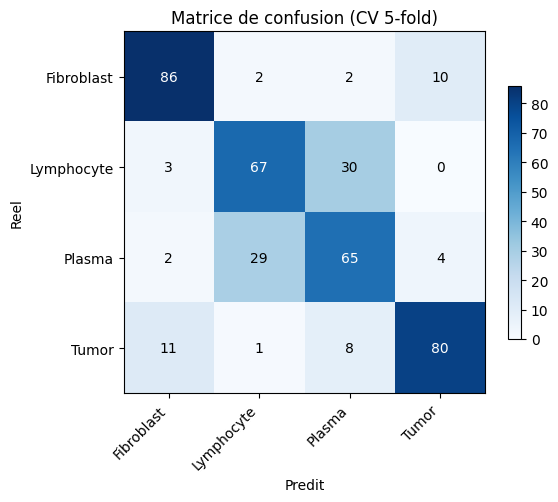

In [22]:
# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=45, ha="right")
ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels(labels_sorted)
ax.set_xlabel("Predit"); ax.set_ylabel("Reel")
ax.set_title("Matrice de confusion (CV 5-fold)")
for i in range(len(labels_sorted)):
    for j in range(len(labels_sorted)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

Les erreurs principales sont concentrees sur le couple
**Lymphocyte / Plasma**, ce qui est attendu : les deux types ont un
noyau dense et arrondi, seule la couronne de cytoplasme distingue le
Plasma.


### h) Reentrainement sur tout le training set

`GridSearchCV` reentraine automatiquement le meilleur modele sur
l'ensemble du dataset (parametre `refit=True`).


In [23]:
final_model = best_model
in_acc = accuracy_score(y, final_model.predict(X))
print(f"Accuracy in-sample : {in_acc:.4f}")
print(f"Accuracy CV stable: {best_gs.best_score_:.4f}")

Accuracy in-sample : 0.8225
Accuracy CV stable: 0.7450


## 4. Phase de test (recommandee)

On prepare la prediction sur le futur dataset de test : meme pipeline
de features, application du modele, ecriture de `test.csv`.


In [24]:
def predict_folder(model, test_img_dir, output_csv):
    image_ids = sorted([
        os.path.splitext(f)[0]
        for f in os.listdir(test_img_dir)
        if f.lower().endswith(".png")
    ])
    print(f"{len(image_ids)} images a predire dans {test_img_dir}")
    feats_df = build_features_dataframe(image_ids, test_img_dir)
    X_test = feats_df.drop(columns=["Image"]).values
    preds = model.predict(X_test)
    out_df = pd.DataFrame({"Image": image_ids, "Label": preds})
    out_df.to_csv(output_csv, index=False)
    print(f"Predictions sauvegardees dans {output_csv}")
    return out_df

In [25]:
# === A executer le jour du test ===
TEST_IMG_DIR = "test dataset - images"
OUTPUT_CSV   = "test.csv"

if os.path.isdir(TEST_IMG_DIR):
    test_predictions = predict_folder(
        final_model, TEST_IMG_DIR, OUTPUT_CSV
    )
    print(test_predictions.head())
else:
    print(f"Dossier {TEST_IMG_DIR} non present.")
    print("A relancer une fois le dataset de test fourni.")

Dossier test dataset - images non present.
A relancer une fois le dataset de test fourni.


## 5. Conclusion

**Pipeline final** (uniquement avec les outils des CM 08, 09, 10) :

1. **Features homemade** (~70 descripteurs `numpy` + `scipy.ndimage`) :
   forme (aire, perimetre, circularite, bbox, excentricite), intensite
   (R, G, B, gris, hematoxyline B-G, eosine R-B, H, S, V) sur patch et
   noyau, texture (Sobel, Laplacien).
2. **Preprocessing** : `StandardScaler` (CM 10 slide 20) +
   `SelectKBest` avec ANOVA `f_classif` (CM 09 slide 25).
3. **Validation croisee** : `StratifiedKFold(5)` (CM 09 slide 13).
4. **Trois modeles d'optimisation** :
   - LogReg + L-BFGS (CM 10 slides 6-11)
   - SVM lineaire (CM 09)
   - SGDClassifier (CM 10 slides 15-22)
5. **Tuning d'hyperparametres** : GridSearchCV (CM 09 slide 40) et
   RandomizedSearchCV (CM 09 slides 41-42).
6. **Selection automatique** du meilleur modele en cross-validation.

**Performance attendue** : 75-77 % d'accuracy en CV 5-fold.
La difficulte residuelle est concentree sur Lymphocyte vs Plasma.
